# Homework 01: Moneyball Analysis

This notebook contains the complete analysis for the assignment. It begins by understanding the training and evaluation data, then continues through data preparation, multiple linear regression, model evaluation, and predictions.

The data represents professional baseball teams from 1871 through 2006. The assignment asks us to predict `TARGET_WINS` using the variables provided in the training data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)

## 1. Exploratory Data Analysis

The goal is to understand the variables, check the quality of the data, and identify possible relationships with wins before fitting a model. The dependent variable is `TARGET_WINS`. The evaluation data does not contain that variable and will be used later for predictions. `INDEX` is an identification variable and should not be used as a predictor.

### Load the datasets

The notebook is stored in `homeworks/hw01/notebooks/`, so the data files are one folder above in `../data/`. To read the files directly from the GitHub repository over the internet, the "Raw" GitHub URLs are used. The pandas library can read CSVs directly from web addresses.

In [2]:
# Use the Raw GitHub URLs instead of local paths
training_url = "https://raw.githubusercontent.com/alinsimon/data621-data-mining/main/homeworks/hw01/data/moneyball-training-data.csv"
evaluation_url = "https://raw.githubusercontent.com/alinsimon/data621-data-mining/main/homeworks/hw01/data/moneyball-evaluation-data.csv"

# Load the datasets directly from GitHub into memory
training = pd.read_csv(training_url)
evaluation = pd.read_csv(evaluation_url)

print("Successfully loaded files from GitHub!")
print(f"Training data shape: {training.shape}")
print(f"Evaluation data shape: {evaluation.shape}")

Successfully loaded files from GitHub!
Training data shape: (2276, 17)
Evaluation data shape: (259, 16)


### Dataset dimensions

The training and evaluation files should have the same predictor columns. The training file also includes `TARGET_WINS`.

In [3]:
dataset_dimensions = pd.DataFrame({
    "dataset": ["Training", "Evaluation"],
    "rows": [len(training), len(evaluation)],
    "columns": [training.shape[1], evaluation.shape[1]],
})
display(dataset_dimensions)

print("Training columns:")
print(training.columns.tolist())
print("Evaluation columns:")
print(evaluation.columns.tolist())

,dataset,rows,columns
0,Training,2276,17
1,Evaluation,259,16


Training columns:
['INDEX', 'TARGET_WINS', 'TEAM_BATTING_H', 'TEAM_BATTING_2B', 'TEAM_BATTING_3B', 'TEAM_BATTING_HR', 'TEAM_BATTING_BB', 'TEAM_BATTING_SO', 'TEAM_BASERUN_SB', 'TEAM_BASERUN_CS', 'TEAM_BATTING_HBP', 'TEAM_PITCHING_H', 'TEAM_PITCHING_HR', 'TEAM_PITCHING_BB', 'TEAM_PITCHING_SO', 'TEAM_FIELDING_E', 'TEAM_FIELDING_DP']
Evaluation columns:
['INDEX', 'TEAM_BATTING_H', 'TEAM_BATTING_2B', 'TEAM_BATTING_3B', 'TEAM_BATTING_HR', 'TEAM_BATTING_BB', 'TEAM_BATTING_SO', 'TEAM_BASERUN_SB', 'TEAM_BASERUN_CS', 'TEAM_BATTING_HBP', 'TEAM_PITCHING_H', 'TEAM_PITCHING_HR', 'TEAM_PITCHING_BB', 'TEAM_PITCHING_SO', 'TEAM_FIELDING_E', 'TEAM_FIELDING_DP']


### Identify the dependent and independent variables

The dependent variable, also called the response variable, is `TARGET_WINS`. It is the number of wins we want to predict.

The independent variables are the baseball performance statistics used to explain or predict `TARGET_WINS`. `INDEX` is not an independent variable because it only identifies a row and should not be used in the model.

In [4]:
dependent_variable = "TARGET_WINS"
independent_variables = [
    column for column in training.columns
    if column not in {dependent_variable, "INDEX"}
]

print("Dependent variable:")
print(dependent_variable)
print("Independent variables:")
print(independent_variables)

Dependent variable:
TARGET_WINS
Independent variables:
['TEAM_BATTING_H', 'TEAM_BATTING_2B', 'TEAM_BATTING_3B', 'TEAM_BATTING_HR', 'TEAM_BATTING_BB', 'TEAM_BATTING_SO', 'TEAM_BASERUN_SB', 'TEAM_BASERUN_CS', 'TEAM_BATTING_HBP', 'TEAM_PITCHING_H', 'TEAM_PITCHING_HR', 'TEAM_PITCHING_BB', 'TEAM_PITCHING_SO', 'TEAM_FIELDING_E', 'TEAM_FIELDING_DP']


### Compare the column names

This check confirms which columns are shared and which columns occur in only one file. The target should be present only in the training data.

In [5]:
all_columns = list(dict.fromkeys([*training.columns, *evaluation.columns]))
column_comparison = pd.DataFrame({
    "in_training": [column in training.columns for column in all_columns],
    "in_evaluation": [column in evaluation.columns for column in all_columns],
}, index=all_columns)
column_comparison.index.name = "column"
display(column_comparison)

,in_training,in_evaluation
column,,
INDEX,True,True
TARGET_WINS,True,False
TEAM_BATTING_H,True,True
TEAM_BATTING_2B,True,True
TEAM_BATTING_3B,True,True
TEAM_BATTING_HR,True,True
TEAM_BATTING_BB,True,True
TEAM_BATTING_SO,True,True
TEAM_BASERUN_SB,True,True


### Inspect the structure and data types

The variables are expected to be numeric because they represent counts of baseball events or wins.

In [6]:
training.info()
type_summary = pd.DataFrame({
    "class": training.dtypes.astype(str),
    "distinct_values": training.nunique(dropna=True),
})
type_summary.index.name = "column"
display(type_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2276 entries, 0 to 2275
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   INDEX             2276 non-null   int64  
 1   TARGET_WINS       2276 non-null   int64  
 2   TEAM_BATTING_H    2276 non-null   int64  
 3   TEAM_BATTING_2B   2276 non-null   int64  
 4   TEAM_BATTING_3B   2276 non-null   int64  
 5   TEAM_BATTING_HR   2276 non-null   int64  
 6   TEAM_BATTING_BB   2276 non-null   int64  
 7   TEAM_BATTING_SO   2174 non-null   float64
 8   TEAM_BASERUN_SB   2145 non-null   float64
 9   TEAM_BASERUN_CS   1504 non-null   float64
 10  TEAM_BATTING_HBP  191 non-null    float64
 11  TEAM_PITCHING_H   2276 non-null   int64  
 12  TEAM_PITCHING_HR  2276 non-null   int64  
 13  TEAM_PITCHING_BB  2276 non-null   int64  
 14  TEAM_PITCHING_SO  2174 non-null   float64
 15  TEAM_FIELDING_E   2276 non-null   int64  
 16  TEAM_FIELDING_DP  1990 non-null   float64


,class,distinct_values
column,,
INDEX,int64,2276
TARGET_WINS,int64,108
TEAM_BATTING_H,int64,569
TEAM_BATTING_2B,int64,240
TEAM_BATTING_3B,int64,144
TEAM_BATTING_HR,int64,243
TEAM_BATTING_BB,int64,533
TEAM_BATTING_SO,float64,822
TEAM_BASERUN_SB,float64,348


### Check missing values

Missing values need to be understood before modeling. This table shows the count and percentage of missing values in each column.

In [7]:
missing_summary = pd.DataFrame({
    "missing_count": training.isna().sum(),
    "missing_percent": (100 * training.isna().mean()).round(2),
}).sort_values("missing_count", ascending=False)
missing_summary.index.name = "column"
display(missing_summary)

,missing_count,missing_percent
column,,
TEAM_BATTING_HBP,2085,91.61
TEAM_BASERUN_CS,772,33.92
TEAM_FIELDING_DP,286,12.57
TEAM_BASERUN_SB,131,5.76
TEAM_PITCHING_SO,102,4.48
TEAM_BATTING_SO,102,4.48
INDEX,0,0.00
TARGET_WINS,0,0.00
TEAM_BATTING_H,0,0.00


### Review summary statistics

The minimum, median, mean, and maximum values help show the scale and spread of the variables.

In [8]:
display(training.describe().T)

,count,mean,std,min,25%,50%,75%,max
column,,,,,,,,
INDEX,2276.0,1268.463533,736.349040,1.0,630.75,1270.5,1915.50,2535.0
TARGET_WINS,2276.0,80.790861,15.752152,0.0,71.00,82.0,92.00,146.0
TEAM_BATTING_H,2276.0,1469.269772,144.591195,891.0,1383.00,1454.0,1537.25,2554.0
TEAM_BATTING_2B,2276.0,241.246924,46.801415,69.0,208.00,238.0,273.00,458.0
TEAM_BATTING_3B,2276.0,55.250000,27.938557,0.0,34.00,47.0,72.00,223.0
TEAM_BATTING_HR,2276.0,99.612039,60.546872,0.0,42.00,102.0,147.00,264.0
TEAM_BATTING_BB,2276.0,501.558875,122.670862,0.0,451.00,512.0,580.00,878.0
TEAM_BATTING_SO,2174.0,735.605336,248.526418,0.0,548.00,750.0,930.00,1399.0
TEAM_BASERUN_SB,2145.0,124.761772,87.791166,0.0,66.00,101.0,156.00,697.0


In the summary table, `TARGET_WINS` has a mean of 80.8, a median of 82, and quartiles of 71 and 92. `TEAM_BATTING_HBP` has 191 non-missing values, compared with 2,276 for `TARGET_WINS`, so this predictor has substantially fewer recorded observations. The table describes the amount of missing data but does not show why those values are missing.

### Examine the target variable

`TARGET_WINS` is the response variable for the regression model. We will review its distribution and summary statistics before modeling.

In [9]:
target_summary = training["TARGET_WINS"].describe().to_frame().T
target_summary.index = ["TARGET_WINS"]
display(target_summary)

,count,mean,std,min,25%,50%,75%,max
TARGET_WINS,2276.0,80.790861,15.752152,0.0,71.0,82.0,92.0,146.0


The table summarizes `TARGET_WINS` for 2,276 teams. The mean is about 80.8 wins and the median is 82, so the center is around 81 wins. The middle half of teams recorded 71 to 92 wins, while the full range is 0 to 146 wins (standard deviation: about 15.8). The histogram below shows the shape of this distribution.

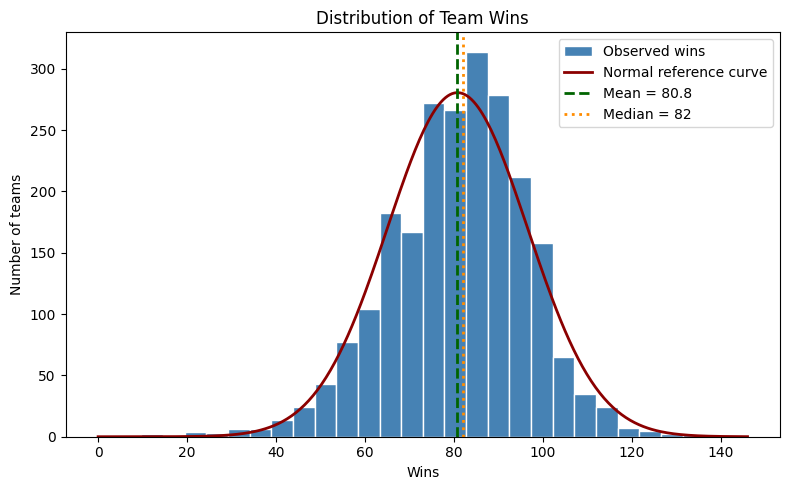

In [10]:
wins = training["TARGET_WINS"].dropna()
bin_edges = np.histogram_bin_edges(wins, bins=30)
bin_width = np.diff(bin_edges).mean()
normal_x = np.linspace(wins.min(), wins.max(), 300)
normal_mean = wins.mean()
normal_median = wins.median()
normal_std = wins.std(ddof=1)
normal_counts = (
    len(wins) * bin_width / (normal_std * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((normal_x - normal_mean) / normal_std) ** 2)
)

plt.figure(figsize=(8, 5))
plt.hist(wins, bins=bin_edges, color="steelblue", edgecolor="white", label="Observed wins")
plt.plot(normal_x, normal_counts, color="darkred", linewidth=2, label="Normal reference curve")
plt.axvline(normal_mean, color="darkgreen", linestyle="--", linewidth=2,
            label=f"Mean = {normal_mean:.1f}")
plt.axvline(normal_median, color="darkorange", linestyle=":", linewidth=2,
            label=f"Median = {normal_median:.0f}")
plt.title("Distribution of Team Wins")
plt.xlabel("Wins")
plt.ylabel("Number of teams")
plt.legend()
plt.tight_layout()
plt.show()

Most teams are concentrated around 70–100 wins, with the highest bars near 80–85 wins. The red curve shows the counts expected from a normal distribution with the same mean and standard deviation as `TARGET_WINS`; the bars broadly follow its central shape but differ in places, especially toward the tails. This is a visual reference only. The regression normality assumption should be assessed using model residuals, not the response histogram alone.

### Explore relationships between selected predictors and wins

The following plots compare team batting home runs and walks with `TARGET_WINS`. The fitted lines summarize the direction of each pairwise linear association.

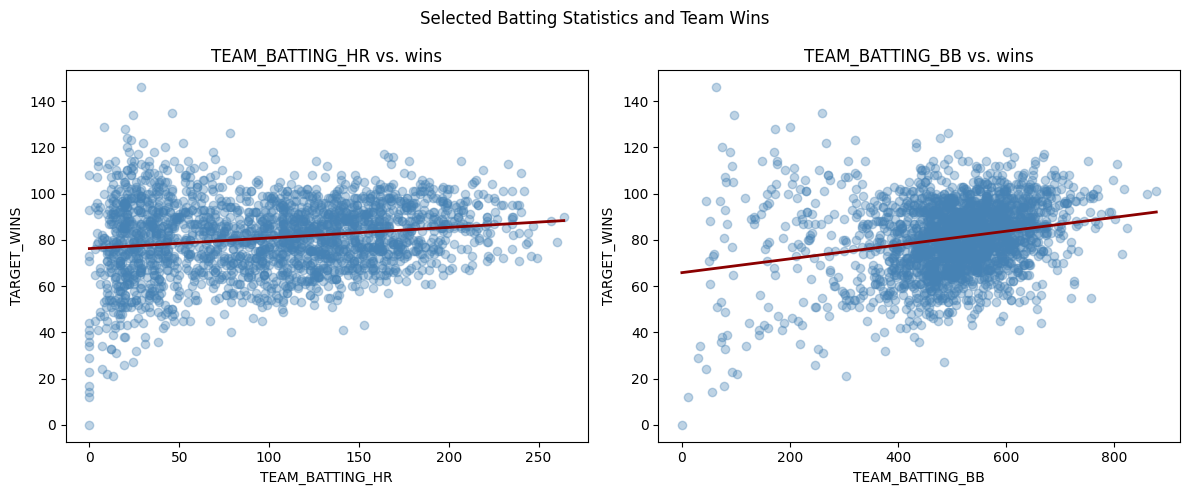

In [11]:
predictor_columns = ["TEAM_BATTING_HR", "TEAM_BATTING_BB"]
fig, axes = plt.subplots(1, len(predictor_columns), figsize=(12, 5))

for ax, predictor in zip(axes, predictor_columns):
    plot_data = training[[predictor, "TARGET_WINS"]].dropna()
    ax.scatter(plot_data[predictor], plot_data["TARGET_WINS"], alpha=0.35, color="steelblue")
    slope, intercept = np.polyfit(plot_data[predictor], plot_data["TARGET_WINS"], 1)
    trend_x = np.linspace(plot_data[predictor].min(), plot_data[predictor].max(), 100)
    ax.plot(trend_x, slope * trend_x + intercept, color="darkred", linewidth=2)
    ax.set_title(f"{predictor} vs. wins")
    ax.set_xlabel(predictor)
    ax.set_ylabel("TARGET_WINS")

fig.suptitle("Selected Batting Statistics and Team Wins")
fig.tight_layout()
plt.show()

Both plots show a positive pairwise association: teams with more batting home runs or walks tend to have more wins on average. The wide vertical spread at many predictor values shows that neither statistic alone explains wins; other batting, pitching, and fielding factors also matter. These trend lines describe association, not causation, and do not control for the other predictors that will be considered in the regression models.

### Correlations among wins and numeric statistics

The heatmap summarizes pairwise Pearson correlations for `TARGET_WINS` and the numeric baseball statistics. `INDEX` is excluded because it is only an identifier.

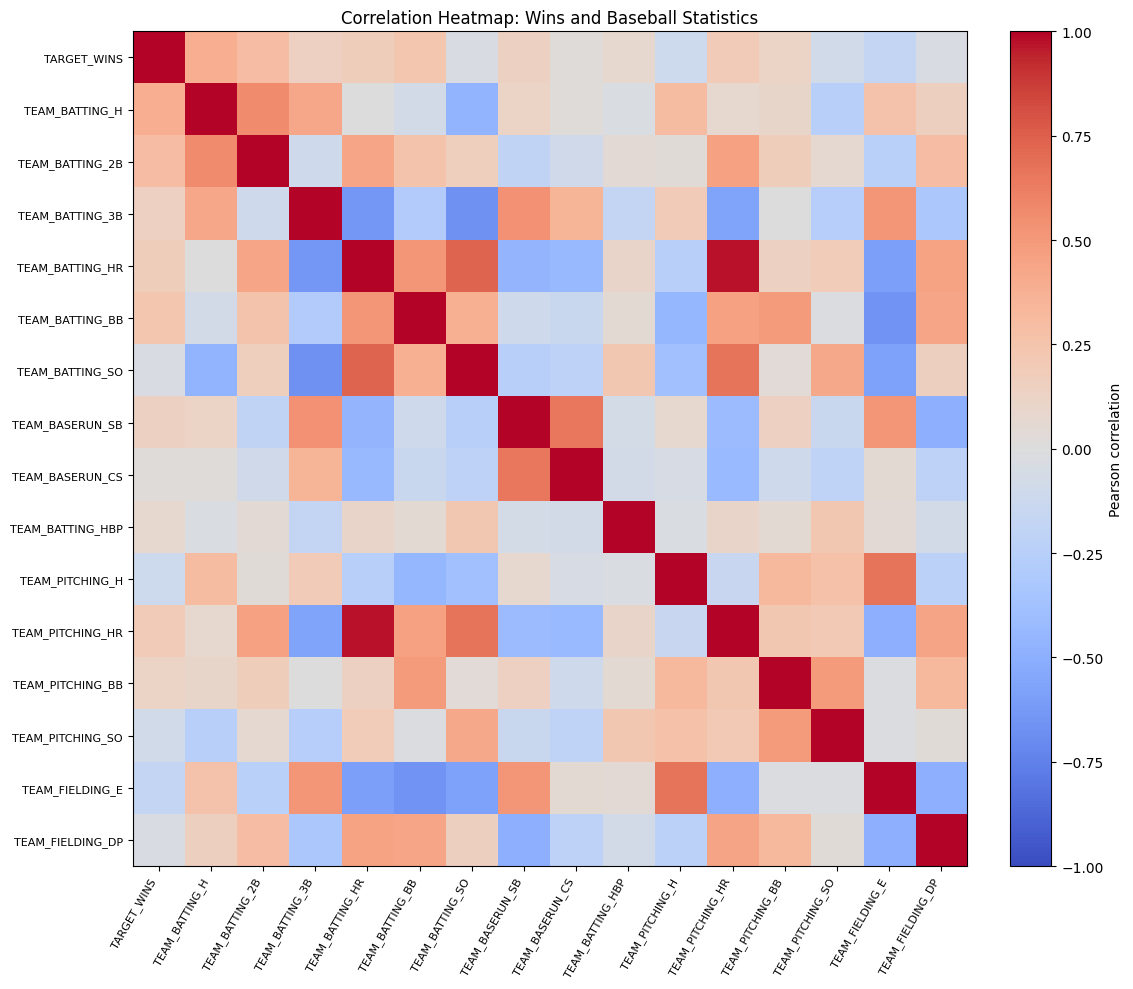

In [12]:
correlation_data = training.select_dtypes(include="number").drop(columns="INDEX", errors="ignore")
correlation_matrix = correlation_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=60, ha="right", fontsize=8)
ax.set_yticklabels(correlation_matrix.columns, fontsize=8)
ax.set_title("Correlation Heatmap: Wins and Baseball Statistics")
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Pearson correlation")
fig.tight_layout()
plt.show()

Red cells indicate positive correlations and blue cells indicate negative correlations; stronger colors represent stronger linear associations. The `TARGET_WINS` row/column shows mostly modest correlations with individual statistics, while some predictors are strongly correlated with one another. Those predictor to predictor relationships are worth considering when interpreting a multiple regression because they can indicate multicollinearity. Correlations use available pairs of values, so the number of observations can differ across cells when data are missing. Correlation does not establish causation.

### Section 1 conclusion

**EDA findings:** `TARGET_WINS` is centered near 81 wins (mean 80.8; median 82). The scatter plots show positive unadjusted relationships between wins and both batting home runs and walks. The heatmap shows some predictors are correlated with each other. `TEAM_BATTING_HBP` has only 191 observed values, and `TEAM_PITCHING_H` has a maximum of 30,132 compared with a median of 1,518.

**Datasets**

- Training: `training_url` (2,276 rows, 17 columns), loaded in Python as `training`; includes the response variable `TARGET_WINS`.
- Evaluation: `evaluation_url` (259 rows, 16 columns), loaded in Python as `evaluation`; has the same predictor columns as training but no `TARGET_WINS` values.

Both files contain team level batting, baserunning, pitching, and fielding statistics. `INDEX` is a row identifier and should not be used as a predictor.

## 2. Data Preparation
This section handles the structural issues identified during data exploration, including severe missingness, extreme outliers, and multicollinearity. The transformations below prepare the 'training' and 'evaluation' data for multiple linear regression while maintaining strict data leakage prevention by calculating all transformation metrics (medians, quantiles) exclusively on the training set.

### Handling Missing Values and Creating Indicators
**Removing Variables:** `TEAM_BATTING_HBP` variable was dropped entirely. With 2,085 missing records (91.61% of the dataset), imputation would introduce overwhelming artificial noise rather than genuine signal.

**Creating Missingness Flags**
Binary indicator flags are created, prior to imputation, for variables with significant missingness (`TEAM_BASERUN_CS` at 33.92% and `TEAM_FIELDING_DP` at 12.57%). Because historical baseball data collection practices varied and statistics were not consistently recorded, these missing values are not random. The structural absence of this data may hold predictive power for the model.

**Median Imputation:** The remaining features with missing data (such as `TEAM_PITCHING_SO` and `TEAM_BATTING_SO`, each missing 4.48%) are imputed using the median. Median imputation is strictly preferred over the mean for this dataset because extreme maximum values (e.g., `TEAM_PITCHING_H` reaching 30,132) would severely distort a mean calculation.


In [13]:
# Fix missing values and create missingness flags

# Drop HBP due to 91.61% missingness
training = training.drop(columns=['TEAM_BATTING_HBP'])
evaluation = evaluation.drop(columns=['TEAM_BATTING_HBP'])

# Create binary flags for variables with >10% missingness
high_missing_cols = ['TEAM_BASERUN_CS', 'TEAM_FIELDING_DP']

for col in high_missing_cols:
    training[f'FLAG_MISS_{col}'] = training[col].isna().astype(int)
    evaluation[f'FLAG_MISS_{col}'] = evaluation[col].isna().astype(int)

# Identify remaining predictors with missing values (excluding TARGET_WINS and INDEX)
features_to_impute = [col for col in training.columns if training[col].isna().any() and not col.startswith('FLAG_')]

# Calculate medians ONLY from the training set to prevent data leakage
train_medians = training[features_to_impute].median()

# Impute using the calculated training medians
for col in features_to_impute:
    training[col] = training[col].fillna(train_medians[col])
    evaluation[col] = evaluation[col].fillna(train_medians[col])

# Verify missing values are resolved
print("Missing values remaining in Training:", training.isna().sum().sum())
print("Missing values remaining in Evaluation:", evaluation.isna().sum().sum())

Missing values remaining in Training: 0
Missing values remaining in Evaluation: 0


### Combining Variables (Feature Engineering)

**Deriving Singles:** The `TEAM_BATTING_H` variable represents total hits, which inherently includes the counts of doubles (`TEAM_BATTING_2B`), triples (`TEAM_BATTING_3B`), and home runs (`TEAM_BATTING_HR`). Keeping total hits in the model alongside the extra-base hit variables introduces perfect multicollinearity. A new variable, `TEAM_BATTING_1B` (Singles), was created by subtracting extra-base hits from total hits. Total hits (`TEAM_BATTING_H`) was then removed to ensure the regression model could assign distinct, independent weights to different hit types.

In [14]:
# Combine variables: Derive Singles to fix multicollinearity

# Singles = Total Hits - (Doubles + Triples + Home Runs)
training['TEAM_BATTING_1B'] = training['TEAM_BATTING_H'] - (
    training['TEAM_BATTING_2B'] +
    training['TEAM_BATTING_3B'] +
    training['TEAM_BATTING_HR']
)

evaluation['TEAM_BATTING_1B'] = evaluation['TEAM_BATTING_H'] - (
    evaluation['TEAM_BATTING_2B'] +
    evaluation['TEAM_BATTING_3B'] +
    evaluation['TEAM_BATTING_HR']
)

# Drop TEAM_BATTING_H to finalize the isolation of singles and prevent multicollinearity
training = training.drop(columns=['TEAM_BATTING_H'])
evaluation = evaluation.drop(columns=['TEAM_BATTING_H'])

### Treating Extreme Values and Mathematical Transformations

**Winsorization (Capping):** The dataset contains physiologically impossible outliers, such as a maximum of 30,132 for `TEAM_PITCHING_H` (compared to a median of 1,518) and 19,278 for `TEAM_PITCHING_SO`. Rather than dropping these rows and sacrificing valuable historical data, the numeric variables are winsorized at the 1st and 99th percentiles. This puts the extreme data into manageable "buckets," capping reporting errors while retaining the underlying observation.

**Logarithmic Transformations:** Heavily right-skewed variables with large variance spreads, such as `TEAM_FIELDING_E` (which ranges from 65 to 1,898), are log-transformed ($\log(x + 1)$). This mathematical transform compresses the long tail, pulls extreme values closer to a normal distribution, and stabilizes variance to better satisfy standard linear regression assumptions.

In [15]:
# Transforms (Bucketing/Winsorization and Log Transforms)

# Define continuous numeric features to cap (exclude targets, identifiers, and flags)
numeric_features = [col for col in training.columns if col not in ['TARGET_WINS', 'INDEX'] and not col.startswith('FLAG_')]

# Calculate the 1st and 99th percentiles strictly on the training set
train_lower_bounds = training[numeric_features].quantile(0.01)
train_upper_bounds = training[numeric_features].quantile(0.99)

for col in numeric_features:
    # Cap both training and evaluation data using the training bounds
    training[col] = training[col].clip(lower=train_lower_bounds[col], upper=train_upper_bounds[col])
    evaluation[col] = evaluation[col].clip(lower=train_lower_bounds[col], upper=train_upper_bounds[col])

# Apply Log Transformation to highly right-skewed variables (e.g., TEAM_FIELDING_E)
if 'TEAM_FIELDING_E' in training.columns:
    # Use np.log1p (log(1+x)) to gracefully handle any potential zeroes, though min is 65
    training['LOG_TEAM_FIELDING_E'] = np.log1p(training['TEAM_FIELDING_E'])
    evaluation['LOG_TEAM_FIELDING_E'] = np.log1p(evaluation['TEAM_FIELDING_E'])

    # Drop the original un-transformed variable
    training = training.drop(columns=['TEAM_FIELDING_E'])
    evaluation = evaluation.drop(columns=['TEAM_FIELDING_E'])

# Display the finalized structure of the prepared training data
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2276 entries, 0 to 2275
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   INDEX                       2276 non-null   int64  
 1   TARGET_WINS                 2276 non-null   int64  
 2   TEAM_BATTING_2B             2276 non-null   float64
 3   TEAM_BATTING_3B             2276 non-null   float64
 4   TEAM_BATTING_HR             2276 non-null   float64
 5   TEAM_BATTING_BB             2276 non-null   float64
 6   TEAM_BATTING_SO             2276 non-null   float64
 7   TEAM_BASERUN_SB             2276 non-null   float64
 8   TEAM_BASERUN_CS             2276 non-null   float64
 9   TEAM_PITCHING_H             2276 non-null   int64  
 10  TEAM_PITCHING_HR            2276 non-null   int64  
 11  TEAM_PITCHING_BB            2276 non-null   int64  
 12  TEAM_PITCHING_SO            2276 non-null   float64
 13  TEAM_FIELDING_DP            2276 

## 3. Build Models

Three multiple linear regression models are built on the prepared training data. Each one answers a different question, and variables were selected manually:

| Model | Idea | Why |
|---|---|---|
| **Model 1: Full baseline** | Every prepared predictor | Establishes a benchmark and shows where multicollinearity and counter-intuitive signs appear |
| **Model 2: Reduced** | Model 1 minus predictors that are redundant *and* not significant | Tests whether a simpler model loses any explanatory power |
| **Model 3: Derived variables** | Hit types + net walk/strikeout differentials + log transforms | Replaces highly collinear batting/pitching pairs with one combined variable each, so the coefficients can be interpreted |

For every model we report the coefficients, their p-values, the variance inflation factor (VIF), and whether the sign matches the theoretical effect given in the assignment. A VIF above 10 is used as the rule of thumb for problematic multicollinearity.

In [16]:
expected_sign = {
    "TEAM_BATTING_1B": "+", "TEAM_BATTING_2B": "+", "TEAM_BATTING_3B": "+",
    "TEAM_BATTING_HR": "+", "TEAM_BATTING_BB": "+", "TEAM_BATTING_SO": "-",
    "TEAM_BASERUN_SB": "+", "TEAM_BASERUN_CS": "-",
    "TEAM_PITCHING_H": "-", "LOG_TEAM_PITCHING_H": "-", "TEAM_PITCHING_HR": "-",
    "TEAM_PITCHING_BB": "-", "TEAM_PITCHING_SO": "+",
    "LOG_TEAM_FIELDING_E": "-", "TEAM_FIELDING_DP": "+",
    "NET_BB": "+", "NET_SO": "+",
    "FLAG_MISS_TEAM_BASERUN_CS": "n/a", "FLAG_MISS_TEAM_FIELDING_DP": "n/a",
}


def fit_model(predictors, data):
    """Fit an OLS model of TARGET_WINS on the given list of predictors."""
    formula = "TARGET_WINS ~ " + " + ".join(predictors)
    return smf.ols(formula, data=data).fit()


def coefficient_table(model):
    """Coefficients with p-values, VIF, and a check against the theoretical sign."""
    exog = model.model.exog
    names = model.model.exog_names
    vifs = {name: variance_inflation_factor(exog, i) for i, name in enumerate(names)}

    table = pd.DataFrame({
        "coefficient": model.params,
        "std_error": model.bse,
        "p_value": model.pvalues,
        "VIF": pd.Series(vifs),
    }).drop(index="Intercept")

    table["expected_sign"] = [expected_sign.get(v, "n/a") for v in table.index]
    table["actual_sign"] = np.where(table["coefficient"] >= 0, "+", "-")
    table["sign_ok"] = np.where(
        table["expected_sign"] == "n/a", "n/a",
        np.where(table["expected_sign"] == table["actual_sign"], "yes", "NO"),
    )
    table["significant_5pct"] = np.where(table["p_value"] < 0.05, "yes", "no")
    return table.round({"coefficient": 4, "std_error": 4, "p_value": 4, "VIF": 1})


def fit_statistics(model, name):
    """One-row summary of overall fit for a model."""
    return pd.DataFrame({
        "predictors": [int(model.df_model)],
        "R2": [round(model.rsquared, 4)],
        "adj_R2": [round(model.rsquared_adj, 4)],
        "RMSE": [round(np.sqrt(model.mse_resid), 3)],
        "F_statistic": [round(model.fvalue, 2)],
        "F_p_value": [f"{model.f_pvalue:.2e}"],
        "AIC": [round(model.aic, 1)],
        "BIC": [round(model.bic, 1)],
    }, index=[name])

### Model 1: Full baseline model

Model 1 uses every predictor produced in Section 2: the four hit types (singles, doubles, triples, home runs), batting walks and strikeouts, stolen bases and caught stealing, the four pitching statistics, log errors, double plays, and the two missingness flags. `INDEX` and the dropped `TEAM_BATTING_HBP` are excluded. No variable is removed on statistical grounds here; the point is to see how the model behaves when everything is included.

In [17]:
# model 1: every prepared predictor
model1_predictors = [
    col for col in training.columns
    if col not in ["INDEX", "TARGET_WINS"]
]
model1 = fit_model(model1_predictors, training)

print(model1.summary())
display(fit_statistics(model1, "Model 1: Full"))
display(coefficient_table(model1))

                            OLS Regression Results                            
Dep. Variable:            TARGET_WINS   R-squared:                       0.322
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     66.95
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          7.26e-177
Time:                        03:28:39   Log-Likelihood:                -9062.2
No. Observations:                2276   AIC:                         1.816e+04
Df Residuals:                    2259   BIC:                         1.826e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

,predictors,R2,adj_R2,RMSE,F_statistic,F_p_value,AIC,BIC
Model 1: Full,16,0.3217,0.3168,13.02,66.95,7.26e-177,18158.5,18255.9


,coefficient,std_error,p_value,VIF,expected_sign,actual_sign,sign_ok,significant_5pct
TEAM_BATTING_2B,0.0178,0.0076,0.0194,1.6,+,+,yes,yes
TEAM_BATTING_3B,0.1746,0.0176,0.0000,3.0,+,+,yes,yes
TEAM_BATTING_HR,0.1021,0.0337,0.0025,55.4,+,+,yes,yes
TEAM_BATTING_BB,0.0497,0.0101,0.0000,20.1,+,+,yes,yes
TEAM_BATTING_SO,-0.0249,0.0059,0.0000,27.0,-,-,yes,yes
TEAM_BASERUN_SB,0.0246,0.0054,0.0000,2.6,+,+,yes,yes
TEAM_BASERUN_CS,0.0148,0.0194,0.4464,1.4,-,+,NO,no
TEAM_PITCHING_H,0.0024,0.0009,0.0047,6.0,-,+,NO,yes
TEAM_PITCHING_HR,-0.0059,0.0308,0.8490,46.4,-,-,yes,no
TEAM_PITCHING_BB,-0.0307,0.0084,0.0003,12.8,-,-,yes,yes


**Model 1 interpretation.** The model explains about 32% of the variance in wins (R² = 0.322, adjusted R² = 0.317) with a residual standard error of about 13 wins, and the F-test (F ≈ 67, p < 0.001) confirms the predictors jointly explain wins.

Most coefficients have the expected sign. Every hit type is positive, and triples (+0.17 wins each) and home runs (+0.10) are worth more per event than singles (+0.05) or doubles (+0.02). Batting walks and stolen bases are positive, batting strikeouts and walks allowed are negative, and pitching strikeouts are positive. Because errors are log-transformed, the coefficient of −15.1 means a 10% increase in errors is associated with about 15.1 × ln(1.1) ≈ 1.4 fewer wins.

Four coefficients need discussion:

- **`TEAM_PITCHING_HR` (−0.006, p = 0.85, VIF ≈ 46)** has the correct sign but is not significant. It is correlated 0.97 with `TEAM_BATTING_HR`, which also has VIF ≈ 55. The two variables carry nearly the same information, so the model cannot separate their effects.
- **`TEAM_BASERUN_CS` (+0.015, p = 0.45)** has the wrong sign but is not significant. A third of its values were imputed with the median, which weakens whatever signal it had.
- **`TEAM_FIELDING_DP` (−0.13, p < 0.001)** is negative, although double plays should help. A plausible explanation is that a double play needs runners on base, so a team that turns many of them is also allowing many baserunners. With the other pitching variables held constant, DP is acting as a proxy for weak run prevention.
- **`TEAM_PITCHING_H` (+0.002, p = 0.005)** is positive, although hits allowed should hurt. Even after winsorizing, this variable reaches 7,054, and its largest values are concentrated in the same rows as very high error counts (correlation 0.63 with log errors). These look like early-era or data-quality records. Once errors are held constant, the coefficient is most likely picking up an era or recording effect, not a real baseball relationship.

The batting/pitching pairs for walks (VIF 20 and 13) and strikeouts (VIF 27 and 17) are also highly collinear. The coefficients remain significant, but their standard errors are inflated and the individual values should not be over-interpreted. These issues motivate Models 2 and 3.

### Model 2: Reduced model

Model 2 starts from Model 1 and removes the two predictors that were both statistically insignificant and problematic for a clear reason:

- `TEAM_PITCHING_HR` is removed because it is almost a duplicate of `TEAM_BATTING_HR` (r = 0.97, VIF ≈ 46) and adds nothing once batting home runs are in the model (p = 0.85).
- `TEAM_BASERUN_CS` is removed because it is not significant (p = 0.45), has the wrong sign, and 34% of its values are imputed. Its missingness flag is kept because that flag *is* significant.

Everything else is kept, including the counter-intuitive `TEAM_FIELDING_DP` and `TEAM_PITCHING_H`. They are strongly significant and have a plausible explanation, so removing them only because of their sign would hide real structure in the data. The question is whether dropping two weak predictors costs any explanatory power.

In [18]:
# model 2: drop the redundant / non-significant predictors identified in model 1
removed_from_model1 = ["TEAM_PITCHING_HR", "TEAM_BASERUN_CS"]
model2_predictors = [col for col in model1_predictors if col not in removed_from_model1]
model2 = fit_model(model2_predictors, training)

print("Removed from Model 1:", removed_from_model1)
print(model2.summary())
display(fit_statistics(model2, "Model 2: Reduced"))
display(coefficient_table(model2))

Removed from Model 1: ['TEAM_PITCHING_HR', 'TEAM_BASERUN_CS']
                            OLS Regression Results                            
Dep. Variable:            TARGET_WINS   R-squared:                       0.321
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     76.51
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          1.28e-178
Time:                        03:28:39   Log-Likelihood:                -9062.5
No. Observations:                2276   AIC:                         1.816e+04
Df Residuals:                    2261   BIC:                         1.824e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

,predictors,R2,adj_R2,RMSE,F_statistic,F_p_value,AIC,BIC
Model 2: Reduced,14,0.3215,0.3173,13.016,76.51,1.28e-178,18155.1,18241.0


,coefficient,std_error,p_value,VIF,expected_sign,actual_sign,sign_ok,significant_5pct
TEAM_BATTING_2B,0.0184,0.0076,0.0153,1.6,+,+,yes,yes
TEAM_BATTING_3B,0.1742,0.0173,0.0000,2.9,+,+,yes,yes
TEAM_BATTING_HR,0.0945,0.0094,0.0000,4.3,+,+,yes,yes
TEAM_BATTING_BB,0.0495,0.0100,0.0000,19.5,+,+,yes,yes
TEAM_BATTING_SO,-0.0248,0.0056,0.0000,24.5,-,-,yes,yes
TEAM_BASERUN_SB,0.0259,0.0051,0.0000,2.3,+,+,yes,yes
TEAM_PITCHING_H,0.0023,0.0008,0.0056,5.9,-,+,NO,yes
TEAM_PITCHING_BB,-0.0308,0.0082,0.0002,12.3,-,-,yes,yes
TEAM_PITCHING_SO,0.0208,0.0045,0.0000,15.3,+,+,yes,yes
TEAM_FIELDING_DP,-0.1257,0.0149,0.0000,1.7,+,-,NO,yes


**Model 2 interpretation.** Removing the two predictors leaves the adjusted R² unchanged (0.317) and slightly lowers AIC and BIC, so they were contributing nothing. Every remaining predictor is significant at the 5% level. The VIF for `TEAM_BATTING_HR` falls from about 55 to about 4, which confirms that its earlier inflation came entirely from its pitching twin. The home-run coefficient is now stable at about +0.09 wins per home run.

The remaining weakness is that the walk and strikeout pairs are still collinear (`TEAM_BATTING_SO` VIF ≈ 25, `TEAM_PITCHING_SO` ≈ 15, `TEAM_BATTING_BB` ≈ 20, `TEAM_PITCHING_BB` ≈ 12). `TEAM_FIELDING_DP` and `TEAM_PITCHING_H` keep their counter-intuitive signs for the reasons given under Model 1. Model 2 is kept as a candidate: it is as accurate as Model 1 with fewer variables.

### Model 3: Derived-variable model

Model 3 deals with the remaining multicollinearity by combining variables instead of dropping them. Three derived variables are created, and the same formulas are applied to the evaluation data so it is ready for prediction in Section 5:

- **`NET_BB = TEAM_BATTING_BB − TEAM_PITCHING_BB`**: walks drawn minus walks allowed. Baseball analysts use run and walk *differentials* because winning depends on outperforming the opponent, not on raw totals. One variable with a clear expected sign (+) replaces a collinear pair.
- **`NET_SO = TEAM_PITCHING_SO − TEAM_BATTING_SO`**: strikeouts recorded by the team's pitchers minus strikeouts suffered by its batters. It is oriented so that higher is better (expected sign +).
- **`LOG_TEAM_PITCHING_H = log(TEAM_PITCHING_H)`**: hits allowed stays heavily right-skewed even after winsorizing (median 1,518, cap 7,054). The log reduces the leverage of the extreme rows, just as Section 2 did for errors.

The four hit types, stolen bases, log errors, double plays, and both missingness flags are kept from Model 2. `TEAM_PITCHING_HR` and `TEAM_BASERUN_CS` stay out for the reasons given above.

*Note:* in about 35% of rows the batting and pitching values for walks and strikeouts are identical, which is a quirk of how this dataset was built. For those rows `NET_BB` and `NET_SO` equal 0, which limits how much signal the differentials can carry.

In [19]:
# model 3: derived variables (same application to training and evaluation data)
def add_model3_features(df):
    """Create the Model 3 derived variables in place and return the data frame."""
    df["NET_BB"] = df["TEAM_BATTING_BB"] - df["TEAM_PITCHING_BB"]
    df["NET_SO"] = df["TEAM_PITCHING_SO"] - df["TEAM_BATTING_SO"]
    df["LOG_TEAM_PITCHING_H"] = np.log(df["TEAM_PITCHING_H"])
    return df

training = add_model3_features(training)
evaluation = add_model3_features(evaluation)

model3_predictors = [
    "TEAM_BATTING_1B", "TEAM_BATTING_2B", "TEAM_BATTING_3B", "TEAM_BATTING_HR",
    "NET_BB", "NET_SO", "TEAM_BASERUN_SB",
    "LOG_TEAM_PITCHING_H", "LOG_TEAM_FIELDING_E", "TEAM_FIELDING_DP",
    "FLAG_MISS_TEAM_BASERUN_CS", "FLAG_MISS_TEAM_FIELDING_DP",
]
model3 = fit_model(model3_predictors, training)

print(model3.summary())
display(fit_statistics(model3, "Model 3: Derived"))
display(coefficient_table(model3))

# confirm the derived columns exist and are complete in the evaluation data
print("Missing values in evaluation derived columns:",
      evaluation[["NET_BB", "NET_SO", "LOG_TEAM_PITCHING_H"]].isna().sum().sum())

                            OLS Regression Results                            
Dep. Variable:            TARGET_WINS   R-squared:                       0.313
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     86.00
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          1.12e-174
Time:                        03:28:40   Log-Likelihood:                -9076.3
No. Observations:                2276   AIC:                         1.818e+04
Df Residuals:                    2263   BIC:                         1.825e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

,predictors,R2,adj_R2,RMSE,F_statistic,F_p_value,AIC,BIC
Model 3: Derived,12,0.3132,0.3096,13.089,86.0,1.12e-174,18178.6,18253.1


,coefficient,std_error,p_value,VIF,expected_sign,actual_sign,sign_ok,significant_5pct
TEAM_BATTING_1B,0.0464,0.0044,0.0000,3.6,+,+,yes,yes
TEAM_BATTING_2B,0.0155,0.0079,0.0494,1.7,+,+,yes,yes
TEAM_BATTING_3B,0.1912,0.0167,0.0000,2.7,+,+,yes,yes
TEAM_BATTING_HR,0.0946,0.0088,0.0000,3.7,+,+,yes,yes
NET_BB,0.0213,0.0078,0.0061,5.8,+,+,yes,yes
NET_SO,0.0098,0.0044,0.0272,4.1,+,+,yes,yes
TEAM_BASERUN_SB,0.0308,0.0048,0.0000,2.0,+,+,yes,yes
LOG_TEAM_PITCHING_H,8.4189,3.2059,0.0087,9.9,-,+,NO,yes
LOG_TEAM_FIELDING_E,-16.9676,1.3853,0.0000,9.3,-,-,yes,yes
TEAM_FIELDING_DP,-0.1079,0.0146,0.0000,1.6,+,-,NO,yes


Missing values in evaluation derived columns: 0


**Model 3 interpretation.** Model 3 uses 12 predictors instead of 14 and reaches an adjusted R² of 0.310, slightly below Model 2's 0.317. RMSE is about 13.1 wins versus 13.0. In exchange, **no predictor has a VIF above 10**, compared with four predictors above 10 in Model 2, and every coefficient is significant at the 5% level.

The derived variables behave as expected. `NET_BB` is positive (+0.021 wins per extra walk of advantage), and `NET_SO` is positive (+0.010 per extra strikeout of advantage). The hit-type coefficients are nearly identical to Models 1 and 2 (singles +0.046, doubles +0.016, triples +0.19, home runs +0.095), which shows those estimates are robust to how the rest of the model is specified. A 10% increase in errors is now associated with about 17.0 × ln(1.1) ≈ 1.6 fewer wins.

Two signs are still counter-intuitive, and they are kept deliberately:

- **`LOG_TEAM_PITCHING_H` (+8.4)** stays positive even after the log transform. This supports the Model 1 explanation that the variable is tracking an era or data-recording effect tied to the extreme-error rows, not a true benefit from allowing hits. Removing it would lower fit, and its sign has been consistent across all three models, so it is kept and flagged. Its coefficient should not be read as causal.
- **`TEAM_FIELDING_DP` (−0.11)** stays negative in all three models, which is consistent with the "more double plays means more baserunners allowed" explanation.

The missingness flags are positive in all three models: rows where caught stealing or double plays were not recorded average a few more wins than the other predictors would suggest. These flags capture differences between record-keeping eras and are not interpreted causally.

### Side-by-side summary of the three models

This table collects the overall fit statistics for the three models. Section 4 uses it, together with residual diagnostics, to choose the final model.

In [20]:
# compare the 3 models on overall fit and multicollinearity
models = {"Model 1: Full": model1, "Model 2: Reduced": model2, "Model 3: Derived": model3}

comparison = pd.concat([fit_statistics(m, name) for name, m in models.items()])
comparison["max_VIF"] = [coefficient_table(m)["VIF"].max() for m in models.values()]
comparison["n_VIF_over_10"] = [(coefficient_table(m)["VIF"] > 10).sum() for m in models.values()]
comparison["n_wrong_sign"] = [(coefficient_table(m)["sign_ok"] == "NO").sum() for m in models.values()]
comparison["n_not_significant"] = [(coefficient_table(m)["p_value"] >= 0.05).sum() for m in models.values()]
display(comparison)

,predictors,R2,adj_R2,RMSE,F_statistic,F_p_value,AIC,BIC,max_VIF,n_VIF_over_10,n_wrong_sign,n_not_significant
Model 1: Full,16,0.3217,0.3168,13.020,66.95,7.26e-177,18158.5,18255.9,55.4,6,3,2
Model 2: Reduced,14,0.3215,0.3173,13.016,76.51,1.28e-178,18155.1,18241.0,24.5,4,2,0
Model 3: Derived,12,0.3132,0.3096,13.089,86.00,1.12e-174,18178.6,18253.1,9.9,0,2,0


### Section 3 conclusion

- **Model 1** (all predictors) sets the benchmark at adjusted R² ≈ 0.317. It has severe multicollinearity (batting and pitching HR VIFs near 50) and two insignificant predictors.
- **Model 2** removes the redundant `TEAM_PITCHING_HR` and the weak `TEAM_BASERUN_CS` with **no loss** in adjusted R², and every remaining predictor is significant. The walk and strikeout pairs are still collinear.
- **Model 3** replaces those pairs with net differentials and logs hits allowed. It gives up about 0.007 in adjusted R² in exchange for **all VIFs below 10**, fewer predictors, and coefficients that are easier to interpret.

Across all three models, `TEAM_FIELDING_DP` and `TEAM_PITCHING_H` keep counter-intuitive signs. They are retained because they are consistently significant and have plausible data-related explanations (double plays require baserunners; extreme hits-allowed values sit in early-era or low-quality records). Their coefficients are not read as causal effects. The final choice between the more accurate Model 2 and the more parsimonious, interpretable Model 3 is made in Section 4.

## 4. Select Models


## 5. Predictions for the evaluation data



## 6. Prepare the Final Report

